In [182]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

In [183]:
X = [2, 0, 2, 2, 7, 4, -2, 5, -1, -1]

def compute_mean(X):
    return np.average(X)

print("Mean : ", compute_mean(X))

Mean :  1.8


In [184]:
X = [1, 5, 4, 4, 9, 13]

def compute_median(X):
    size = len(X)
    middle = int(size/2)
    X = np.sort(X)
    print(X)

    if (size % 2 == 0):
        return (X[middle - 1] + X[middle - 2])/2
    else:
        return X[middle-1]

print("Median: ", compute_median(X))

[ 1  4  4  5  9 13]
Median:  4.0


In [185]:
def compute_std(X):
    mean = compute_mean(X)
    variance = 0

    for i in X:
        variance += (i - mean)**2

    variance /= len(X)

    return np.sqrt(variance)


X = [ 171, 176, 155, 167, 169, 182]
print(compute_std(X))

8.32666399786453


In [186]:
def compute_correlation_cofficient(X, Y):
    N = len(X)
    numerator = 0
    denominator = 0

    mean_X = compute_mean(X)
    mean_Y = compute_mean(Y)

    numerator = np.sum((X - mean_X) * (Y - mean_Y))

    denominator = np.sqrt(np.sum((X - mean_X)**2) * np.sum((Y - mean_Y)**2))

    return np.round(numerator/denominator, 2)

X = np.asarray([-2, -5, -11, 6, 4, 15, 9])
Y = np.asarray([4, 25, 121, 36, 16, 225, 81])
print("Correlation: ", compute_correlation_cofficient(X,Y))

Correlation:  0.42


In [187]:
data = pd.read_csv("data/advertising.csv")

def correlation(x, y):
    covariance = np.cov(x, y)[0, 1]
    std_x = np.std(x, ddof=1)
    std_y = np.std(y, ddof=1)

    return covariance / (std_x * std_y)

x = data['TV']
y = data['Radio']
corr_xy = correlation(x, y)
print(f"Correlation between TV and Sales: {round(corr_xy, 2)}")

Correlation between TV and Sales: 0.05


In [188]:
features = ['TV', 'Radio', 'Newspaper']

for feature_1 in features:
    for feature_2 in features:
        correlation_value = correlation(data[feature_1], data[feature_2])
        print(f"Correlation between {feature_1} and {feature_2}: {round(correlation_value, 2)}")

Correlation between TV and TV: 1.0
Correlation between TV and Radio: 0.05
Correlation between TV and Newspaper: 0.06
Correlation between Radio and TV: 0.05
Correlation between Radio and Radio: 1.0
Correlation between Radio and Newspaper: 0.35
Correlation between Newspaper and TV: 0.06
Correlation between Newspaper and Radio: 0.35
Correlation between Newspaper and Newspaper: 1.0


In [189]:
x = data['Radio']
y = data['Newspaper']

result = np.corrcoef(x, y)
print(result)

[[1.         0.35410375]
 [0.35410375 1.        ]]


In [190]:
data.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


<Axes: >

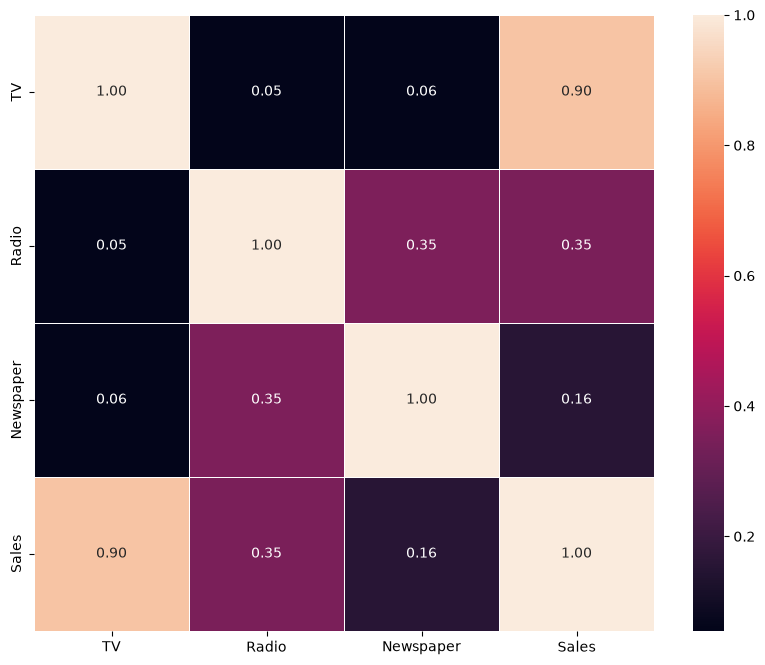

In [191]:
plt.figure(figsize=(10,8))
data_corr = data.corr()
sns.heatmap(data_corr, annot=True, fmt=".2f", linewidth=.5)

In [192]:
vi_data_df = pd.read_csv("data/vi_text_retrieval.csv")
context = vi_data_df['text']
context = [doc.lower() for doc in context]

tfidf_vectorizer = TfidfVectorizer()
context_embedded = tfidf_vectorizer.fit_transform(context)

context_embedded.toarray()[7][0]

np.float64(0.31126580760710637)

In [193]:
def tfidf_search(question, tfidf_vectorizer, top_d=5):
    query_embedded = tfidf_vectorizer.transform([question.lower()])
    cosine_scores = cosine_similarity(context_embedded, query_embedded).reshape((-1,))

    results = []
    for idx in cosine_scores.argsort()[-top_d:][::-1]:
        doc_score = {
            'id': idx,
            'cosine_score':cosine_scores[idx]
        }
        results.append(doc_score)
    return results

question = vi_data_df.iloc[0]['question']
results = tfidf_search(question, tfidf_vectorizer, top_d=5)
results[0]['cosine_score']

np.float64(0.6279910475266973)

In [194]:
def corr_search(question, tfidf_vectorizer, top_d=5):
    query_embedded = tfidf_vectorizer.transform([question.lower()])
    corr_scores = np.corrcoef(
        query_embedded.toarray()[0],
        context_embedded.toarray()
    )

    corr_scores = corr_scores[0][1:]

    results = []

    for idx in corr_scores.argsort()[-top_d:][::-1]:
        doc = {
            'id': idx,
            'corr_score':corr_scores[idx]
        }
        results.append(doc)

    return results

question = vi_data_df.iloc[0]['question']
results = corr_search(question, tfidf_vectorizer, top_d=5)
results[1]['corr_score']

np.float64(0.20734246471973253)

In [195]:
docs = [
    "Học máy là một nhánh của trí tuệ nhân tạo",
    "Trí tuệ nhân tạo bao gồm học máy và mạng nơ ron",
    "Mạng nơ ron là một mô hình quan trọng trong học sâu",
    "Học sâu là một lĩnh vực của trí tuệ nhân tạo và học máy"
]

In [196]:
def build_vocabulary(docs):
    vocab_set = set()
    for doc in docs:
        words = doc.lower().split()
        vocab_set.update(words)
    vocab = sorted(list(vocab_set))
    return vocab

In [197]:
def compute_tf(docs, vocab):
    tf = np.zeros((len(docs), len(vocab)))
    for doc_idx, doc in enumerate(docs):
        words = doc.lower().split()
        for i, term in enumerate(vocab):
            tf[doc_idx, i] = words.count(term) / len(words)
    return tf

In [198]:
def compute_idf(docs, vocab):
    N = len(docs)
    idf = np.zeros(len(vocab))
    for i, term in enumerate(vocab):
        df = sum([1 for doc in docs if term in doc.lower().split()])
        idf[i] = np.log((N + 1) / (df + 1)) + 1
    return idf

In [199]:
def compute_tfidf(tf, idf):
    tf_idf = tf * idf
    return tf_idf

In [200]:
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    return dot_product / (norm1 * norm2)

In [201]:
vocab = build_vocabulary(docs)
tf = compute_tf(docs, vocab)
idf = compute_idf(docs, vocab)

tf_idf_matrix = compute_tfidf(tf, idf)
num_docs = len(docs)

similarity_matrix = np.zeros((num_docs, num_docs))

for i in range(num_docs):
    for j in range(num_docs):
        similarity_matrix[i, j] = cosine_similarity(tf_idf_matrix[i], tf_idf_matrix[j])

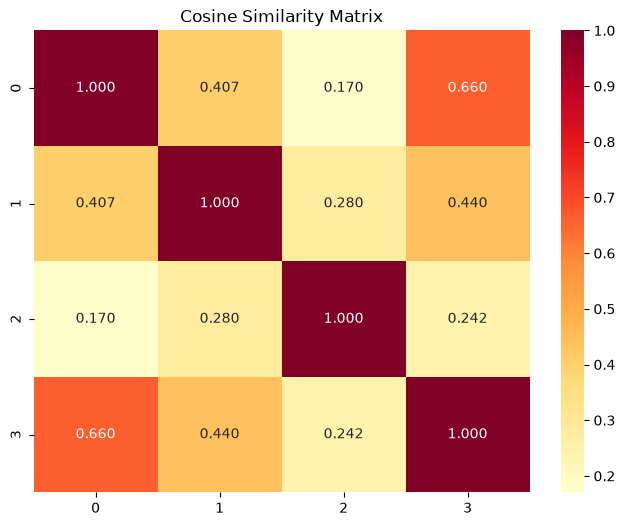

In [202]:
plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix , annot =True , fmt='.3f', cmap='YlOrRd')
plt.title('Cosine Similarity Matrix')
plt.show()